# Data Loading
Dataset from: https://www.kaggle.com/datasets/tawsifurrahman/covid19-radiography-database

In [11]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Set paths
covid_path = '/kaggle/input/covid19-radiography-database/COVID-19_Radiography_Dataset/COVID/images'
normal_path = '/kaggle/input/covid19-radiography-database/COVID-19_Radiography_Dataset/Normal/images'

In [12]:
# List image files
covid_images = [os.path.join(covid_path, img) for img in os.listdir(covid_path) if img.endswith('.png')]
normal_images = [os.path.join(normal_path, img) for img in os.listdir(normal_path) if img.endswith('.png')]

# Balance the dataset
min_len = min(len(covid_images), len(normal_images))
covid_images = covid_images[:min_len]
normal_images = normal_images[:min_len]

# Create labels
covid_labels = ['1'] * len(covid_images)
normal_labels = ['0'] * len(normal_images)

# Combine and split data
all_images = covid_images + normal_images
all_labels = covid_labels + normal_labels

data = pd.DataFrame({'image_path': all_images, 'label': all_labels})
train_df, test_df = train_test_split(data, test_size=0.2, stratify=data['label'], random_state=42)

In [13]:
# ImageDataGenerator for data augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_dataframe(
    train_df,
    x_col='image_path',
    y_col='label',
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary'
)

test_generator = test_datagen.flow_from_dataframe(
    test_df,
    x_col='image_path',
    y_col='label',
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 5785 validated image filenames belonging to 2 classes.
Found 1447 validated image filenames belonging to 2 classes.


In [15]:
# Load the pretrained MobileNetV2 model
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze the base model
base_model.trainable = False

# Build the model
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
model_checkpoint = ModelCheckpoint('covid_classifier_mobilenet.keras', save_best_only=True)

# Train the model
history = model.fit(
    train_generator,
    epochs=50,
    validation_data=test_generator,
    callbacks=[early_stopping, model_checkpoint]
)

Epoch 1/50


/opt/conda/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


  1/181 ━━━━━━━━━━━━━━━━━━━━ 53:20 18s/step - accuracy: 0.5312 - loss: 0.8927

I0000 00:00:1719683614.758202      84 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


181/181 ━━━━━━━━━━━━━━━━━━━━ 131s 629ms/step - accuracy: 0.7738 - loss: 0.4955 - val_accuracy: 0.8328 - val_loss: 0.3579
Epoch 2/50
181/181 ━━━━━━━━━━━━━━━━━━━━ 76s 403ms/step - accuracy: 0.8345 - loss: 0.3616 - val_accuracy: 0.8749 - val_loss: 0.3008
Epoch 3/50
181/181 ━━━━━━━━━━━━━━━━━━━━ 76s 404ms/step - accuracy: 0.8562 - loss: 0.3234 - val_accuracy: 0.8825 - val_loss: 0.2846
Epoch 4/50
181/181 ━━━━━━━━━━━━━━━━━━━━ 76s 403ms/step - accuracy: 0.8662 - loss: 0.3103 - val_accuracy: 0.8915 - val_loss: 0.2580
Epoch 5/50
181/181 ━━━━━━━━━━━━━━━━━━━━ 76s 404ms/step - accuracy: 0.8835 - loss: 0.2776 - val_accuracy: 0.8984 - val_loss: 0.2393
Epoch 6/50
181/181 ━━━━━━━━━━━━━━━━━━━━ 75s 400ms/step - accuracy: 0.8722 - loss: 0.2946 - val_accuracy: 0.9060 - val_loss: 0.2407
Epoch 7/50
181/181 ━━━━━━━━━━━━━━━━━━━━ 77s 409ms/step - accuracy: 0.8883 - loss: 0.2806 - val_accuracy: 0.8818 - val_loss: 0.2756
Epoch 8/50
181/181 ━━━━━━━━━━━━━━━━━━━━ 76s 404ms/step - accuracy: 0.8790 - loss: 0.2761 - va

46/46 ━━━━━━━━━━━━━━━━━━━━ 5s 97ms/step - accuracy: 0.9177 - loss: 0.1835
Test Accuracy: 93.30%
46/46 ━━━━━━━━━━━━━━━━━━━━ 10s 162ms/step
              precision    recall  f1-score   support

      Normal       0.92      0.95      0.93       724
       COVID       0.95      0.92      0.93       723

    accuracy                           0.93      1447
   macro avg       0.93      0.93      0.93      1447
weighted avg       0.93      0.93      0.93      1447



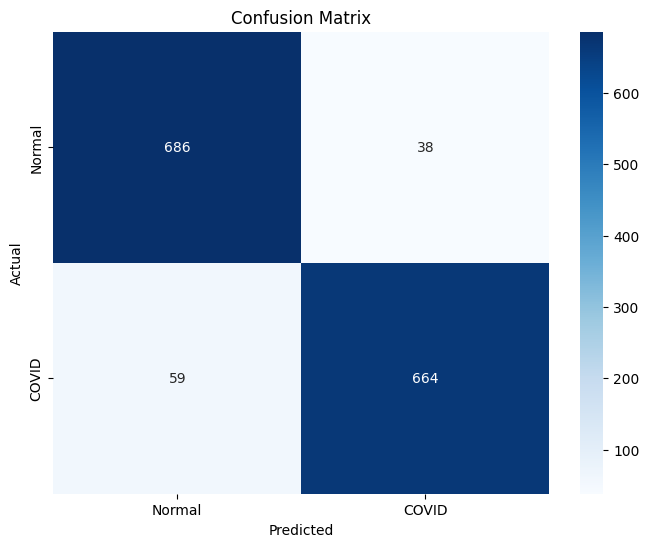

In [16]:
# Load the best model
model.load_weights('covid_classifier_mobilenet.keras')

# Evaluate the model
loss, accuracy = model.evaluate(test_generator)
print(f'Test Accuracy: {accuracy * 100:.2f}%')

# Predictions
test_generator.reset()
predictions = model.predict(test_generator)
predicted_labels = (predictions > 0.5).astype(int).ravel()

# Classification Report
print(classification_report(test_df['label'].astype(int), predicted_labels, target_names=['Normal', 'COVID']))

# Confusion Matrix
conf_matrix = confusion_matrix(test_df['label'].astype(int), predicted_labels)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'COVID'], yticklabels=['Normal', 'COVID'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

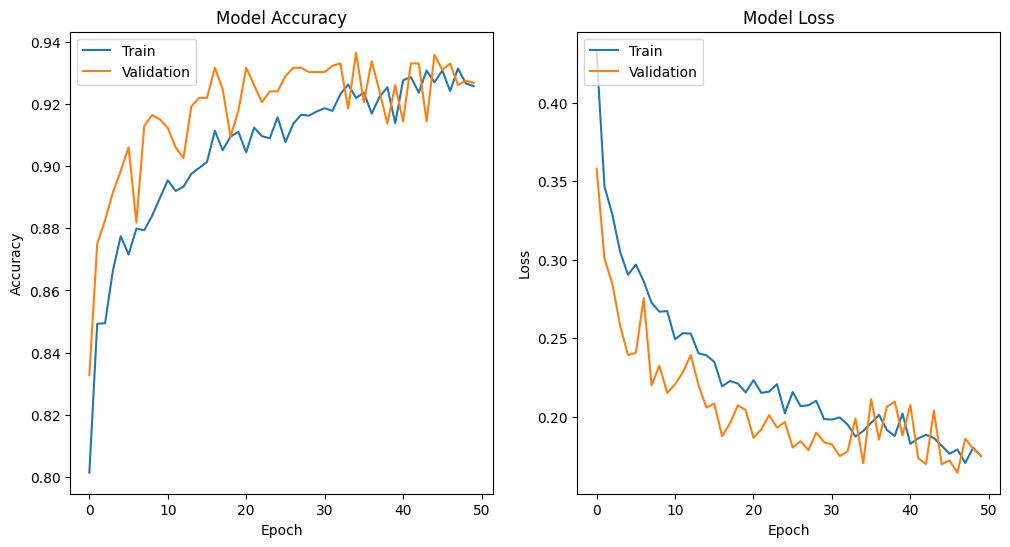

In [18]:
# Plot training & validation accuracy values
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.show()